<a href="https://colab.research.google.com/github/Tjandak/Jandak/blob/main/OOP_mapy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗺️ OpenStreetMap + Python
Stáhneme část Prahy a prozkoumáme strukturu grafu.

[OpenStreetMap.org](https://www.openstreetmap.org/)

In [11]:
%pip install osmnx

In [12]:
!pip install osmnx

In [13]:
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
#import networkx as nx

## 1) Stažení dat

In [14]:
import osmnx as ox

stred = (50.0755, 14.4378)   # Václavské náměstí (lat, lon)
polomer = 1000               # metrů

G = ox.graph_from_point(stred, dist=polomer, network_type='drive')

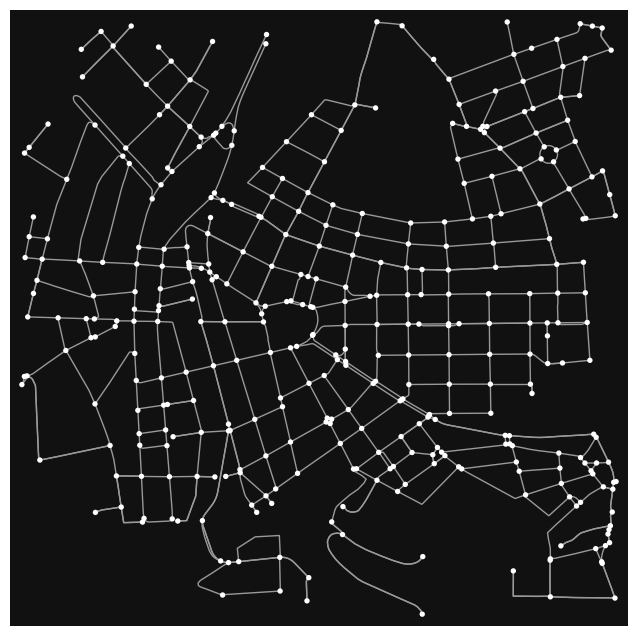

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [15]:
ox.plot_graph(G)

## 2) Základní informace o grafu
Graf.number_of_nodes(),Graf.number_of_edges

In [16]:
# Počet uzlů a hran
print(f"Počet uzlů (křižovatek): {G.number_of_nodes()}")
print(f"Počet hran (úseků cest): {G.number_of_edges()}")

Počet uzlů (křižovatek): 371
Počet hran (úseků cest): 694


In [17]:
pocet_uzlu, pocet_hran = len(G.nodes), len(G.edges)
display([pocet_uzlu, pocet_hran])

[371, 694]

## 3) Struktura uzlu — slovník

In [18]:
type(G.nodes)  # specialni trida NetworkX, má metodu __iter__ (funguje list)

networkx.classes.reportviews.NodeView

In [19]:
list(G.nodes(data=True))[0] # tuple (cislo, slovnik)

(247746, {'y': 50.0773089, 'x': 14.4247582, 'street_count': 4})

In [20]:
# Pro první uzel vypíšeme id_uzlu i slovník data uzlu,
#degree bývá vyšší než street_count, protože jedna obousměrná ulice jsou dvě hrany
id_uzlu, data_uzlu = list(G.nodes(data=True))[0]

print(f"ID uzlu (OSM číslo): {id_uzlu}")
print(f"Typ dat uzlu: {type(data_uzlu)}")
for klic, hodnota in data_uzlu.items():
    print(f"'{klic}': {hodnota}")

ID uzlu (OSM číslo): 247746
Typ dat uzlu: <class 'dict'>
'y': 50.0773089
'x': 14.4247582
'street_count': 4


### Vypiš informaci o zeměpisné šířce a délce uzlu 20, např. "Uzel číslo 2197228: 50.0755 N, 14.4328 E"

https://www.openstreetmap.org/node/25936035

 100 m odpovídá změně přibližně 0.001° pro zeměpisnou šířku i délku.

**Varianta 1**

In [21]:
node_id = list(G.nodes)[20]
lat = G.nodes[node_id]["y"]
lon = G.nodes[node_id]["x"]
print(f"Uzel číslo {node_id}: {lat:.4f} N, {lon:.4f} E")

Uzel číslo 21453764: 50.0772 N, 14.4292 E


**Varianta 2**

In [22]:
node_id = list(G.nodes)[20]
print(f"Uzel číslo {node_id}: {G.nodes[node_id]['y']:.4f} N, {G.nodes[node_id]['x']:.4f} E")

Uzel číslo 21453764: 50.0772 N, 14.4292 E


## 4) Struktura hrany — tuple(start, cil,slovník)

defaultně je data = False - vypíše NODE ID pro start, cíl a nakonec nezajímavý identifikátor hrany pro multigraf.

In [23]:
list(G.edges)[0]  # specialni trida NetworkX, má metodu __iter__ (funguje list)

(247746, 25935957, 0)

In [24]:
list(G.edges(data=True))[10]

(8809993,
 12878702472,
 {'osmid': [325508897, 68172942],
  'highway': 'primary',
  'lanes': '3',
  'maxspeed': '50',
  'name': 'Legerova',
  'oneway': True,
  'ref': '8',
  'reversed': False,
  'length': np.float64(142.33904821799374),
  'geometry': <LINESTRING (14.431 50.069, 14.431 50.069, 14.431 50.07, 14.431 50.07, 14.43...>})

Užitím osmid můžeme hranu zobrazit v OSM: https://www.openstreetmap.org/way/217476454

In [25]:
# Výpis pro první hranu
u, v, data_hrany = list(G.edges(data=True))[0]

print(f"Hrana: uzel {u}  →  uzel {v}")
print(f"Typ dat hrany: {type(data_hrany)}")
print()
for klic, hodnota in data_hrany.items():
    if klic == 'geometry':
        print(f"  '{klic}': <geometrie>")
    else:
        print(f"  '{klic}': {hodnota}")

Hrana: uzel 247746  →  uzel 25935957
Typ dat hrany: <class 'dict'>

  'osmid': 128494848
  'highway': residential
  'lanes': 1
  'name': Štěpánská
  'oneway': True
  'reversed': False
  'length': 70.50731856403189
  'geometry': <geometrie>


### Vypiš informaci o 10. hraně, např. "osmid 217476454: Rumunská",

Vytvoř string pro URL na hranu

https://www.openstreetmap.org/way/217476454


In [26]:
edge = list(G.edges(data=True))[10]
osmid = edge[2]["osmid"]
name = edge[2].get("name", "bez názvu")

print(f"osmid {osmid}: {name}")

url = f"https://www.openstreetmap.org/way/{osmid}"
print(url)

osmid [325508897, 68172942]: Legerova
https://www.openstreetmap.org/way/[325508897, 68172942]


## 5) Zajímavé statistiky

Užijeme hodnoty klíče `length` ve slovníku `data_hrany`

* Nejkratší úsek:  2.8 m
* Nejdelší úsek:   207.6 m
* Průměrná délka:  76.9 m
* Celková délka:   18.16 km

In [27]:
# Délky hran
delky = [data_hrany['length'] for u, v, data_hrany in G.edges(data=True) if 'length' in data_hrany]

print(f"Nejkratší úsek:  {min(delky):.1f} m")
print(f"Nejdelší úsek:   m")
print(f"Průměrná délka:  m")
print(f"Celková délka:   km")

Nejkratší úsek:  2.8 m
Nejdelší úsek:   m
Průměrná délka:  m
Celková délka:   km


Užijeme hodnoty klíče `highway` ve slovníku `data_hrany`
* residential               139 úseků
* tertiary                  68 úseků
*  secondary                 21 úseků
* living_street             5 úseků

In [28]:
# Typy ulic
typy = {}
for u, v, d in G.edges(data=True):
    typ = d.get('highway', 'neznámý')
    if isinstance(typ, list):
        typ = typ[0]
    typy[typ] = typy.get(typ, 0) + 1

print("Typy ulic:")
for typ, pocet in sorted(typy.items(), key=lambda x: -x[1]):
    print(f"  {typ:<25} {pocet} úseků")

Typy ulic:
  residential               435 úseků
  tertiary                  169 úseků
  primary                   46 úseků
  secondary                 27 úseků
  living_street             13 úseků
  tertiary_link             2 úseků
  secondary_link            1 úseků
  primary_link              1 úseků


In [29]:
# Křižovatka s nejvíce cestami
stupne = dict(G.degree())
id_max = max(stupne, key=stupne.get)

print(f"Nejsložitější křižovatka:")
print(f"  ID uzlu:      {id_max}")
print(f"  Počet cest:   {stupne[id_max]}")

Nejsložitější křižovatka:
  ID uzlu:      25936040
  Počet cest:   8


## 6) Nejbližší uzel k zadaným souřadnicím

In [30]:
#import numpy as np, zanedbám np.sqrt

def nejblizsi_uzel(G, lon, lat):
    # Projde všechny uzly a najde nejbližší k zadanému bodu
    # n - NODE ID, d['x'] - délka, d['y'] - šířka
    uzly = [(n, d['x'], d['y']) for n, d in G.nodes(data=True)]
    vzdalenosti = [(n, ((x - lon)**2 + (y - lat)**2)) for n, x, y in uzly]
    return min(vzdalenosti, key=lambda x: x[1])[0]

# Zadej libovolné souřadnice (lon, lat)
lon = 14.4350
lat = 50.0760

uzel = nejblizsi_uzel(G, lon, lat)
data = G.nodes[uzel]

print(f"Hledám uzel nejblíže: lon={lon}, lat={lat}")
print(f"  ID uzlu: {uzel}")
print(f"  Souřadnice uzlu: lon={data['x']:.5f}, lat={data['y']:.5f}")

Hledám uzel nejblíže: lon=14.435, lat=50.076
  ID uzlu: 25936052
  Souřadnice uzlu: lon=14.43484, lat=50.07599


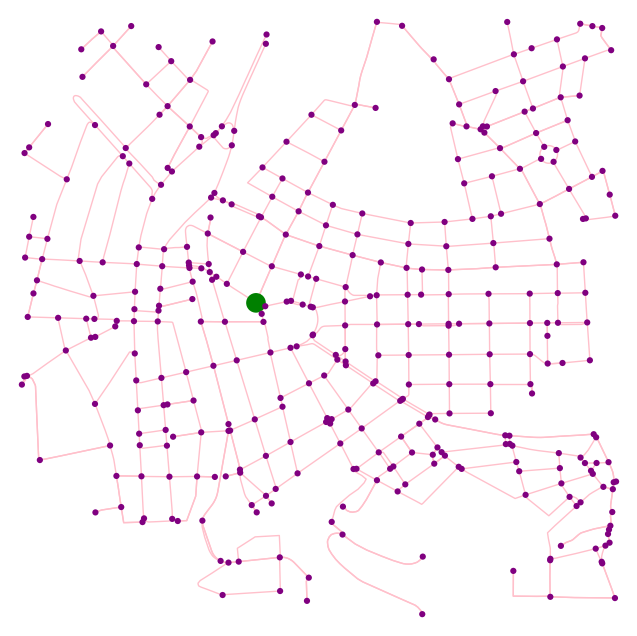

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [31]:
node = 25936052

node_sizes  = [200 if n == node else 20 for n in G.nodes]
node_colors = ["green" if n == node else "purple" for n in G.nodes]

ox.plot_graph(G, node_size=node_sizes, node_color=node_colors,
              edge_color="pink", bgcolor="white")

**Vlasntí Mapa**

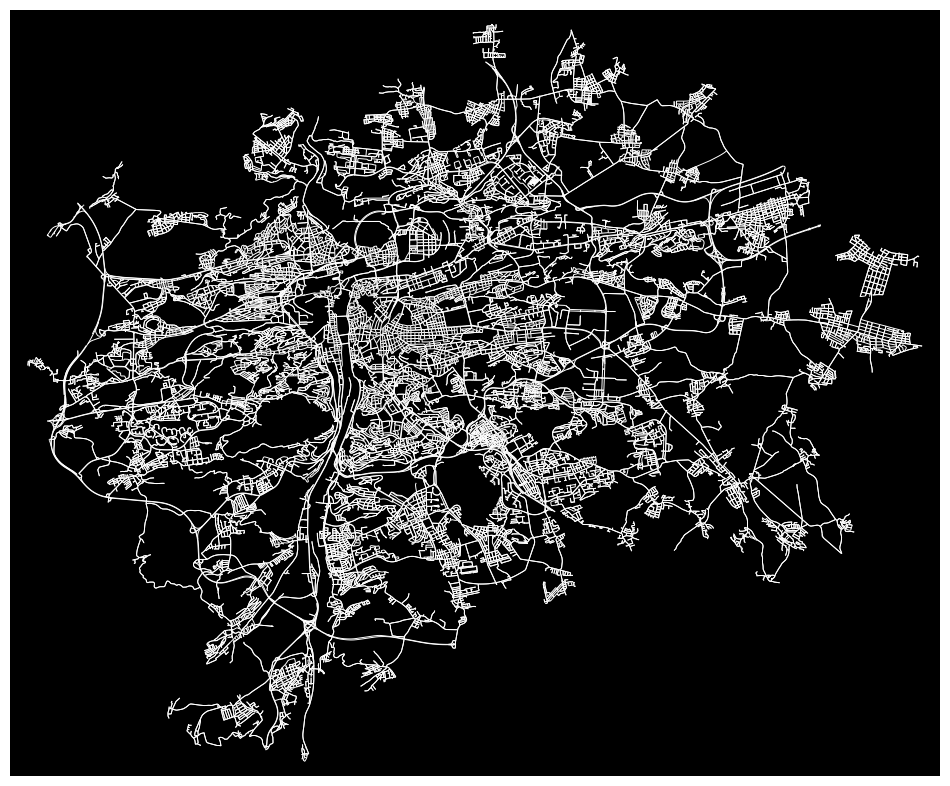

In [34]:
import osmnx as ox
import matplotlib.pyplot as plt

G = ox.graph_from_place("Prague, Czechia", network_type="drive")

fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="white",
    edge_linewidth=0.7,
    bgcolor="black",
    figsize=(12,12)
)

plt.show()

In [35]:
import osmnx as ox

G = ox.graph_from_place("Prague, Czech Republic", network_type="drive")

lat, lon = 50.0755, 14.4378

closest_node = ox.nearest_nodes(G, lon, lat)

node_lat = G.nodes[closest_node]["y"]
node_lon = G.nodes[closest_node]["x"]

url = f"https://www.openstreetmap.org/node/{closest_node}"

print(f"Uzel číslo {closest_node}: {node_lat:.6f} N, {node_lon:.6f} E")
print(url)

Uzel číslo 26395545: 50.075851 N, 14.437516 E
https://www.openstreetmap.org/node/26395545


**Moje město**

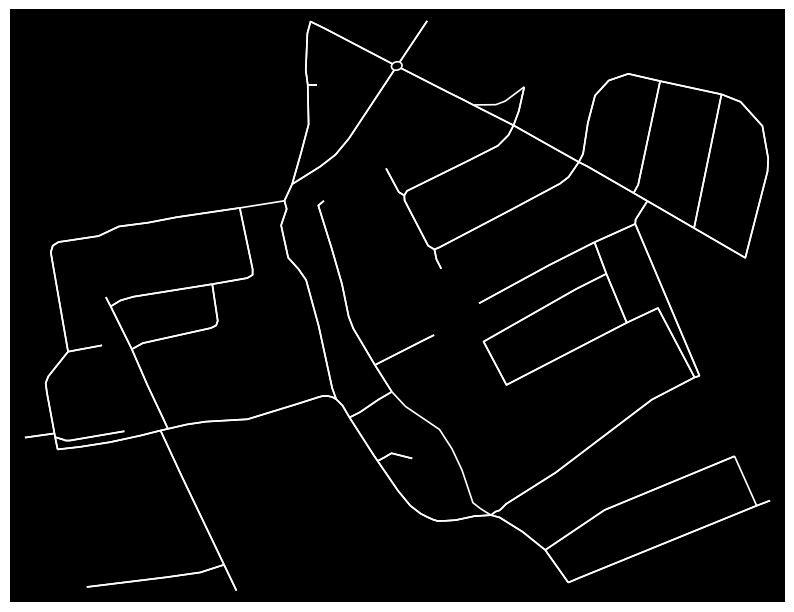

In [43]:
import osmnx as ox
import matplotlib.pyplot as plt

bbox = (14.195, 50.026, 14.210, 50.036)

G = ox.graph_from_bbox(bbox=bbox, network_type="drive")

fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="white",
    edge_linewidth=1.2,
    bgcolor="black",
    figsize=(10, 10)
)

plt.show()

**Základní informace**

In [48]:
import osmnx as ox

bbox = (14.195, 50.026, 14.210, 50.036)
G = ox.graph_from_bbox(bbox=bbox, network_type="drive")

print(f"Počet uzlů (křižovatek): {G.number_of_nodes()}")
print(f"Počet hran (úseků cest): {G.number_of_edges()}")

Počet uzlů (křižovatek): 60
Počet hran (úseků cest): 140


**Struktura uzlů**

In [44]:
import osmnx as ox

bbox = (14.195, 50.026, 14.210, 50.036)
G = ox.graph_from_bbox(bbox=bbox, network_type="drive")

lat, lon = 50.0327, 14.2066

closest_node = ox.nearest_nodes(G, lon, lat)

node_lat = G.nodes[closest_node]["y"]
node_lon = G.nodes[closest_node]["x"]

url = f"https://www.openstreetmap.org/node/{closest_node}"

print(f"Uzel číslo {closest_node}: {node_lat:.6f} N, {node_lon:.6f} E")
print(url)

Uzel číslo 1749837178: 50.032991 N, 14.207358 E
https://www.openstreetmap.org/node/1749837178


**Struktura Hran**

In [45]:
import osmnx as ox

bbox = (14.195, 50.026, 14.210, 50.036)
G = ox.graph_from_bbox(bbox=bbox, network_type="drive")

u, v, data_hrany = list(G.edges(data=True))[0]

print(f"Hrana: uzel {u}  →  uzel {v}")
print(f"Typ dat hrany: {type(data_hrany)}")
print()

for klic, hodnota in data_hrany.items():
    if klic == 'geometry':
        print(f"  '{klic}': <geometrie>")
    else:
        print(f"  '{klic}': {hodnota}")

Hrana: uzel 73321729  →  uzel 344229713
Typ dat hrany: <class 'dict'>

  'osmid': 30957513
  'highway': living_street
  'maxspeed': 20
  'name': Lípová
  'oneway': False
  'reversed': False
  'length': 236.74819291281398
  'geometry': <geometrie>


**Statistiky**

In [46]:
import osmnx as ox

bbox = (14.195, 50.026, 14.210, 50.036)
G = ox.graph_from_bbox(bbox=bbox, network_type="drive")

delky = [data_hrany['length'] for u, v, data_hrany in G.edges(data=True) if 'length' in data_hrany]

print(f"Nejkratší úsek:  {min(delky):.1f} m")
print(f"Nejdelší úsek:   {max(delky):.1f} m")
print(f"Průměrná délka:  {sum(delky)/len(delky):.1f} m")
print(f"Celková délka:   {sum(delky)/1000:.2f} km")

Nejkratší úsek:  4.2 m
Nejdelší úsek:   365.0 m
Průměrná délka:  100.6 m
Celková délka:   14.09 km


**Nejbližší uzel**

In [47]:
import osmnx as ox

bbox = (14.195, 50.026, 14.210, 50.036)
G = ox.graph_from_bbox(bbox=bbox, network_type="drive")

lat, lon = 50.0327, 14.2066

closest_node = ox.nearest_nodes(G, lon, lat)

node_lat = G.nodes[closest_node]["y"]
node_lon = G.nodes[closest_node]["x"]

print(f"Nejbližší uzel: {closest_node}")
print(f"Souřadnice uzlu: {node_lat:.6f} N, {node_lon:.6f} E")
print(f"OpenStreetMap URL: https://www.openstreetmap.org/node/{closest_node}")

Nejbližší uzel: 1749837178
Souřadnice uzlu: 50.032991 N, 14.207358 E
OpenStreetMap URL: https://www.openstreetmap.org/node/1749837178


**Nejkomplikovanější uzel**

In [49]:
import osmnx as ox

bbox = (14.195, 50.026, 14.210, 50.036)
G = ox.graph_from_bbox(bbox=bbox, network_type="drive")

degrees = dict(G.degree())
nejkomplicovanejsi_uzel = max(degrees, key=degrees.get)
pocet_hranic = degrees[nejkomplicovanejsi_uzel]

node_lat = G.nodes[nejkomplicovanejsi_uzel]["y"]
node_lon = G.nodes[nejkomplicovanejsi_uzel]["x"]

print(f"Nejkomplikovanější uzel: {nejkomplicovanejsi_uzel}")
print(f"Počet hran u uzlu: {pocet_hranic}")
print(f"Souřadnice: {node_lat:.6f} N, {node_lon:.6f} E")
print(f"OpenStreetMap URL: https://www.openstreetmap.org/node/{nejkomplicovanejsi_uzel}")

Nejkomplikovanější uzel: 2575043219
Počet hran u uzlu: 8
Souřadnice: 50.034492 N, 14.205897 E
OpenStreetMap URL: https://www.openstreetmap.org/node/2575043219


**Kolikrát se uzel se stupněm st v grafu G vyskytuje**

In [50]:
import osmnx as ox

bbox = (14.195, 50.026, 14.210, 50.036)
G = ox.graph_from_bbox(bbox=bbox, network_type="drive")

st = 3
degrees = dict(G.degree())
pocet_uzlu_s_tymto_stupnem = sum(1 for d in degrees.values() if d == st)

print(f"Počet uzlů se stupněm {st}: {pocet_uzlu_s_tymto_stupnem}")

Počet uzlů se stupněm 3: 2


**Vyznačení komplikovaného uzlu**

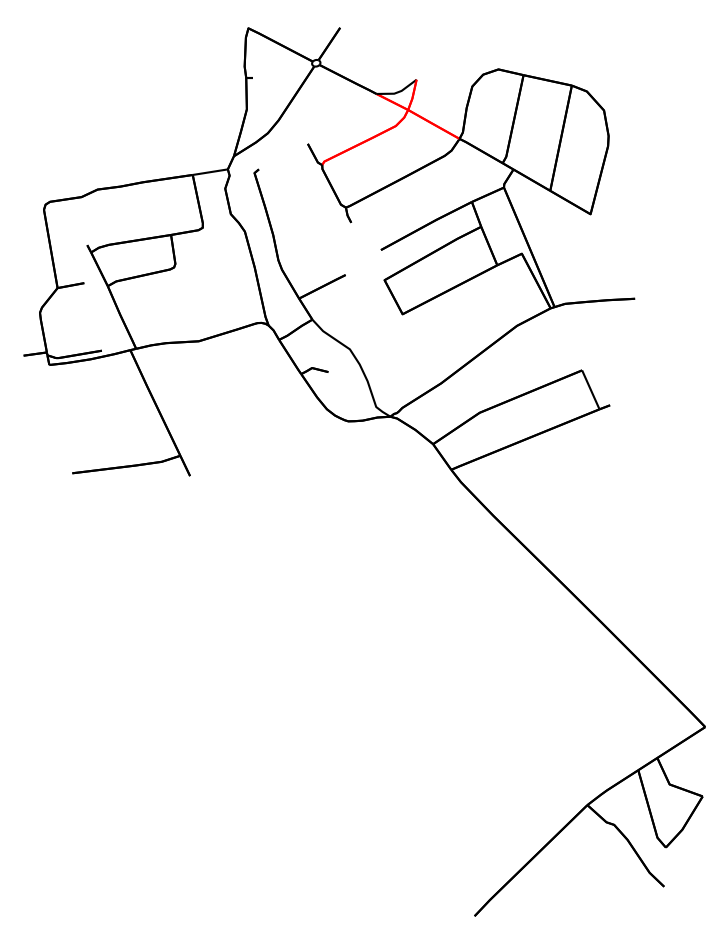

In [54]:
import osmnx as ox
import matplotlib.pyplot as plt

west, south, east, north = 14.195, 50.026, 14.210, 50.036
margin = 0.002

bbox = (west - margin, south - margin, east + margin, north + margin)
G = ox.graph_from_bbox(bbox=bbox, network_type="drive")

degrees = dict(G.degree())
nejkomplicovanejsi_uzel = max(degrees, key=degrees.get)

edge_colors = []
for u, v, data in G.edges(data=True):
    if nejkomplicovanejsi_uzel in (u, v):
        edge_colors.append("red")
    else:
        edge_colors.append("black")

fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=1.5,
    bgcolor="white",
    figsize=(12, 12),
    show=True
)

**Křižovatka s nejvíce cestami**

In [55]:
import osmnx as ox

west, south, east, north = 14.195, 50.026, 14.210, 50.036
G = ox.graph_from_bbox(bbox=(west, south, east, north), network_type="drive")

degrees = dict(G.degree())
nejvetsi_krizovatka = max(degrees, key=degrees.get)
pocet_hranic = degrees[nejvetsi_krizovatka]

node_lat = G.nodes[nejvetsi_krizovatka]["y"]
node_lon = G.nodes[nejvetsi_krizovatka]["x"]

print(f"Křižovatka s nejvíce cestami: {nejvetsi_krizovatka}")
print(f"Počet cest: {pocet_hranic}")
print(f"Souřadnice: {node_lat:.6f} N, {node_lon:.6f} E")
print(f"OpenStreetMap URL: https://www.openstreetmap.org/node/{nejvetsi_krizovatka}")

Křižovatka s nejvíce cestami: 2575043219
Počet cest: 8
Souřadnice: 50.034492 N, 14.205897 E
OpenStreetMap URL: https://www.openstreetmap.org/node/2575043219
